In [11]:
# Шаг 1. Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, binom
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.power import TTestIndPower

# Для PSM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Для анализа мощности
from statsmodels.stats.power import TTestIndPower

# Настройки
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

In [12]:
# Шаг 2. Загрузка данных
readiness_df = pd.read_csv('/content/company_readiness_for_pro.csv')
print(f"Загружено компаний: {len(readiness_df)}")
print(readiness_df.head())

companies = pd.read_csv('/content/01_crm_companies.csv')
finance = pd.read_csv('/content/05_finance_payments.csv')
lms_events = pd.read_csv('/content/03_lms_events.csv')

Загружено компаний: 40
   company_id            company_name      industry region  employee_count  \
0        1001           ООО "Ромашка"        Retail    ЦФО             120   
1        1002        АО "ТехноСервис"            IT   СЗФО              45   
2        1003              ИП Сидоров      Services    ЮФО               5   
3        1004  ООО "Ромашка-Логистик"     Logistics    ЦФО              30   
4        1005       ЗАО "СтройИнвест"  Construction    ПФО             250   

     status  is_active_lms  login_count_90d  payment_stability  avg_check  \
0    active            1.0              1.0                1.0   175000.0   
1    active            1.0              1.0                1.0   335000.0   
2      lead            1.0              1.0                1.0    82500.0   
3    active            0.0              0.0                0.0        0.0   
4  inactive            1.0              1.0                1.0   500000.0   

   total_revenue  norm_avg_check  readiness_s

In [17]:
# Определение пилотной группы

print("Распределение readiness_score:")
print(readiness_df['readiness_score'].describe())
print(f"\n70-й процентиль: {readiness_df['readiness_score'].quantile(0.7):.3f}")
print(f"80-й процентиль: {readiness_df['readiness_score'].quantile(0.8):.3f}")

# ВАШ ПОРОГ (из практической работы №2)
threshold = 0.759

print(f"\nИспользуемый порог: {threshold:.3f}")

# Формируем пилотную группу
pilot_companies = readiness_df[readiness_df['readiness_score'] >= threshold].copy()
pilot_companies['in_pilot'] = 1

print(f"\nПилотная группа: {len(pilot_companies)} компаний")
print(f"Это {len(pilot_companies)/len(readiness_df)*100:.1f}% от всех компаний")

print("\nКомпании в пилотной группе:")
print(pilot_companies[['company_id', 'company_name', 'readiness_score']].to_string(index=False))

Распределение readiness_score:
count    40.000000
mean      0.561582
std       0.311793
min       0.000000
25%       0.413750
50%       0.728200
75%       0.778750
max       1.000000
Name: readiness_score, dtype: float64

70-й процентиль: 0.759
80-й процентиль: 0.798

Используемый порог: 0.759

Пилотная группа: 12 компаний
Это 30.0% от всех компаний

Компании в пилотной группе:
 company_id          company_name  readiness_score
       1001         ООО "Ромашка"            0.805
       1002      АО "ТехноСервис"            0.901
       1005     ЗАО "СтройИнвест"            1.000
       1007    ООО "Торговый Дом"            0.808
       1011    ООО "МедиаХолдинг"            0.952
       1017 АО "Цифровые Решения"            0.820
       1020       ООО "Инновации"            0.844
       1021         АО "СтройТех"            0.775
       1023      ООО "ЭнергоПром"            0.772
       1024   АО "ЛогистикСистем"            0.796
       1025          ООО "ФинТех"            0.790
       

In [14]:
# Проверка названий колонок в CRM файле
print("Колонки в 01_crm_companies.csv:")
print(companies.columns.tolist())

Колонки в 01_crm_companies.csv:
['company_id', 'company_name', 'inn', 'industry', 'region', 'employee_count', 'created_date', 'status']


In [29]:
# Шаг 3. Подготовка данных для модели оценки склонности (Propensity Score)

# 1. Создаем model_df на основе readiness_df
model_df = readiness_df.copy()
print(f"ШАГ 1: model_df создан, размер: {model_df.shape}")

# 2. Добавляем in_pilot
model_df['in_pilot'] = 0
model_df.loc[model_df['company_id'].isin(pilot_companies['company_id']), 'in_pilot'] = 1
print(f"ШАГ 2: in_pilot добавлен, пилотных: {model_df['in_pilot'].sum()}")

# 3. Проверяем, какие колонки уже есть в model_df
print(f"\nКолонки в model_df до добавления region/industry:")
print(f"  {model_df.columns.tolist()}")

# 4. ВНИМАНИЕ: колонки region и industry УЖЕ ЕСТЬ в readiness_df!
# Поэтому нам НЕ НУЖНО их добавлять из CRM!
print("\nШАГ 3: Проверка наличия region и industry...")
if 'region' in model_df.columns:
    print(" region уже есть в model_df (из витрины)")
else:
    print(" region НЕТ в model_df")

if 'industry' in model_df.columns:
    print(" industry уже есть в model_df (из витрины)")
else:
    print(" industry НЕТ в model_df")

# 5. Числовые признаки (из витрины)
print("\nШАГ 4: Числовые признаки...")
numeric_features = []

for col in ['employee_count', 'avg_check', 'payment_stability']:
    if col in model_df.columns:
        numeric_features.append(col)
        print(f" {col}")

# Логины
if 'login_count_90d' in model_df.columns:
    numeric_features.append('login_count_90d')
    print(f" login_count_90d")
elif 'login_count' in model_df.columns:
    numeric_features.append('login_count')
    print(f" login_count")
elif 'is_active_lms' in model_df.columns:
    numeric_features.append('is_active_lms')
    print(f" is_active_lms")

print(f"\nЧисловые признаки: {numeric_features}")

# Создаем числовую матрицу
X_numeric = model_df[numeric_features].copy()
X_numeric = X_numeric.fillna(0)

# 6. Категориальные признаки (region, industry) — берем из model_df, они уже есть!
print("\nШАГ 5: Категориальные признаки...")
X_categorical = pd.get_dummies(model_df[['region', 'industry']], drop_first=True)
print(f"  Создано {X_categorical.shape[1]} dummy-переменных")

# 7. Объединяем
X = pd.concat([X_numeric, X_categorical], axis=1)
y = model_df['in_pilot']

print(f"\n ИТОГО:")
print(f"   X: {X.shape[0]} строк, {X.shape[1]} признаков")
print(f"   y: {y.sum()} пилотных, {(y == 0).sum()} контрольных")
print(f"   Пропусков в X: {X.isnull().sum().sum()}")

print("\nПервые 3 строки X:")
print(X.head(3))

ШАГ 1: model_df создан, размер: (40, 13)
ШАГ 2: in_pilot добавлен, пилотных: 12

Колонки в model_df до добавления region/industry:
  ['company_id', 'company_name', 'industry', 'region', 'employee_count', 'status', 'is_active_lms', 'login_count_90d', 'payment_stability', 'avg_check', 'total_revenue', 'norm_avg_check', 'readiness_score', 'in_pilot']

ШАГ 3: Проверка наличия region и industry...
 region уже есть в model_df (из витрины)
 industry уже есть в model_df (из витрины)

ШАГ 4: Числовые признаки...
 employee_count
 avg_check
 payment_stability
 login_count_90d

Числовые признаки: ['employee_count', 'avg_check', 'payment_stability', 'login_count_90d']

ШАГ 5: Категориальные признаки...
  Создано 11 dummy-переменных

 ИТОГО:
   X: 40 строк, 15 признаков
   y: 12 пилотных, 28 контрольных
   Пропусков в X: 0

Первые 3 строки X:
   employee_count  avg_check  payment_stability  login_count_90d  region_СЗФО  \
0             120   175000.0                1.0              1.0        False 


Первые 10 компаний с propensity scores:
   company_id            company_name  in_pilot  propensity_score
0        1001           ООО "Ромашка"         1          0.678177
1        1002        АО "ТехноСервис"         1          0.835940
2        1003              ИП Сидоров         0          0.056762
3        1004  ООО "Ромашка-Логистик"         0          0.003484
4        1005       ЗАО "СтройИнвест"         1          0.941466
5        1006      ООО "Айти-Решения"         0          0.097119
6        1007      ООО "Торговый Дом"         1          0.667989
7        1008    ООО "Бизнес-Консалт"         0          0.000644
8        1009        АО "ФинансГрупп"         0          0.451839
9        1010           ООО "ПромТех"         0          0.018665


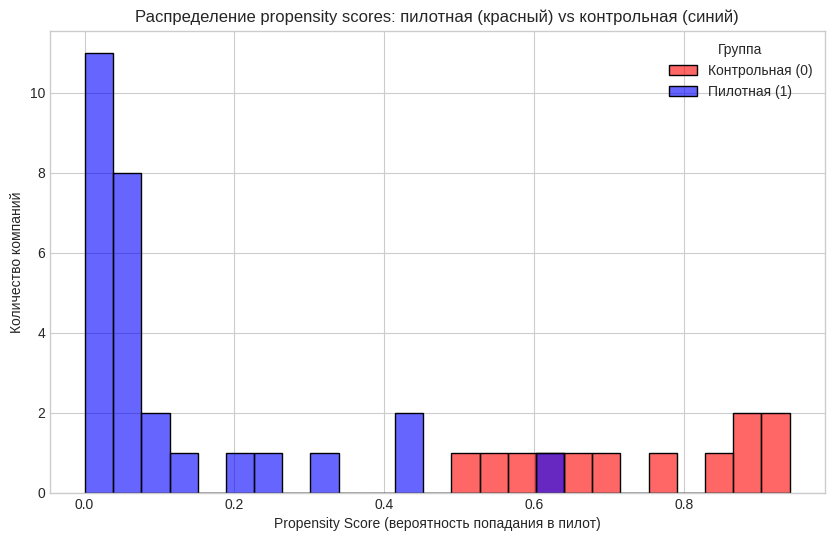

In [30]:
# Шаг 4.Построение модели склонности (Propensity Score Model)

# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучение логистической регрессии
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_scaled, y)

# Получение propensity scores
propensity_scores = logreg.predict_proba(X_scaled)[:, 1]
model_df['propensity_score'] = propensity_scores

# Вывод первых результатов
print("\nПервые 10 компаний с propensity scores:")
print(model_df[['company_id', 'company_name', 'in_pilot', 'propensity_score']].head(10))

# Визуализация распределения
plt.figure(figsize=(10, 6))
sns.histplot(data=model_df, x='propensity_score', hue='in_pilot',
             bins=25, alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('Распределение propensity scores: пилотная (красный) vs контрольная (синий)')
plt.xlabel('Propensity Score (вероятность попадания в пилот)')
plt.ylabel('Количество компаний')
plt.legend(title='Группа', labels=['Контрольная (0)', 'Пилотная (1)'])
plt.show()

Пилотная группа (treated): 12 компаний
Контрольная группа (control): 28 компаний

Поиск ближайших соседей...
Среднее расстояние между парами: 0.1504
Минимальное расстояние: 0.0037
Максимальное расстояние: 0.3308

Подобранная контрольная группа: 12 компаний
Пилотная группа: 12 компаний


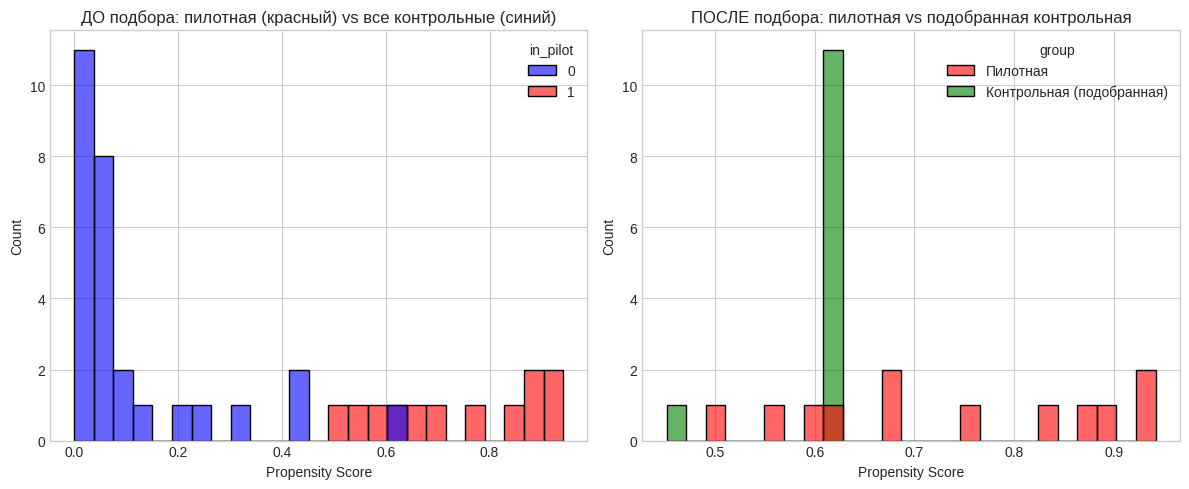


 Итоговые группы для анализа:
  Пилотная: 12 компаний
  Контрольная: 12 компаний


In [31]:
# Шаг 5. Подбор контрольной группы (Matching)
# Разделяем на пилотную и контрольную
treated = model_df[model_df['in_pilot'] == 1].copy()
control = model_df[model_df['in_pilot'] == 0].copy()

print(f"Пилотная группа (treated): {len(treated)} компаний")
print(f"Контрольная группа (control): {len(control)} компаний")

# Подготовка массивов для подбора
treated_scores = treated['propensity_score'].values.reshape(-1, 1)
control_scores = control['propensity_score'].values.reshape(-1, 1)

# Поиск ближайших соседей (1:1)
print("\nПоиск ближайших соседей...")
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control_scores)

distances, indices = nn.kneighbors(treated_scores)
print(f"Среднее расстояние между парами: {distances.mean():.4f}")
print(f"Минимальное расстояние: {distances.min():.4f}")
print(f"Максимальное расстояние: {distances.max():.4f}")

# Создаем подобранную контрольную группу
matched_indices = indices.flatten()
matched_control = control.iloc[matched_indices].copy()
matched_control = matched_control.reset_index(drop=True)
treated_reset = treated.reset_index(drop=True)

print(f"\nПодобранная контрольная группа: {len(matched_control)} компаний")
print(f"Пилотная группа: {len(treated_reset)} компаний")

# Визуализация качества подбора
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=model_df, x='propensity_score', hue='in_pilot',
             bins=25, alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('ДО подбора: пилотная (красный) vs все контрольные (синий)')
plt.xlabel('Propensity Score')

plt.subplot(1, 2, 2)
combined_after = pd.concat([
    treated_reset[['propensity_score']].assign(group='Пилотная'),
    matched_control[['propensity_score']].assign(group='Контрольная (подобранная)')
])
sns.histplot(data=combined_after, x='propensity_score', hue='group',
             bins=25, alpha=0.6, palette={'Пилотная': 'red', 'Контрольная (подобранная)': 'green'})
plt.title('ПОСЛЕ подбора: пилотная vs подобранная контрольная')
plt.xlabel('Propensity Score')

plt.tight_layout()
plt.show()

# Сохраняем для дальнейшего анализа
treated_final = treated_reset
control_final = matched_control

print(f"\n Итоговые группы для анализа:")
print(f"  Пилотная: {len(treated_final)} компаний")
print(f"  Контрольная: {len(control_final)} компаний")

Пред-пилотный период: 2025-01-01 - 2025-03-31
Компаний с выручкой в пред-пилотный период: 32

Компаний в финальном анализе: 24
Из них с ненулевой выручкой: 23

Стандартное отклонение выручки (SD) = 162,297 руб.

Пост-хок анализ мощности...

 При заданных параметрах мощность 80% не достигается ни при каком d ≤ 1.0
  При d=1.0 мощность составит 0.65


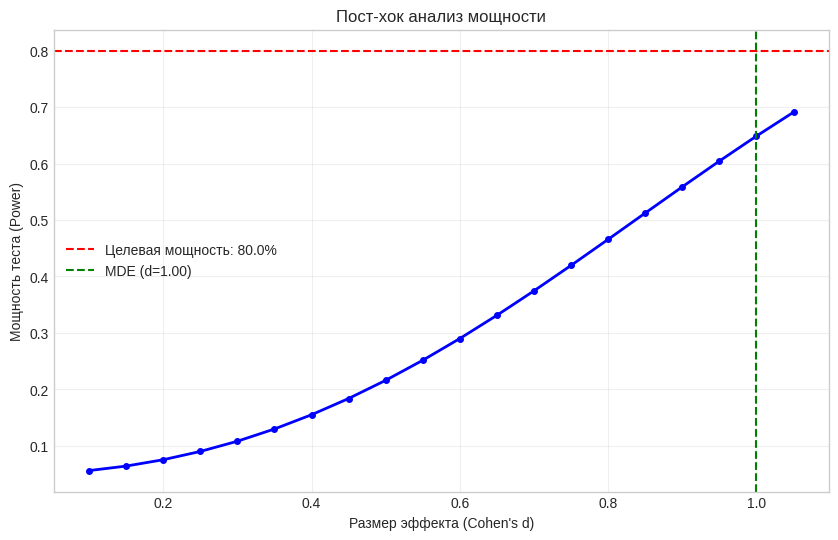

In [32]:
# Шаг 7. Пост-хок анализ чувствительности (Post-hoc Power Analysis)

# Преобразование дат в finance (если не сделано)
finance['doc_date'] = pd.to_datetime(finance['doc_date'], format='%d.%m.%Y')

# Пред-пилотный период (Q1 2025)
pre_start = pd.to_datetime('2025-01-01')
pre_end = pd.to_datetime('2025-03-31')
print(f"Пред-пилотный период: {pre_start.date()} - {pre_end.date()}")

# Фильтруем платежи за пред-пилотный период
pre_payments = finance[
    (finance['payment_type'] == 'payment') &
    (finance['amount'] > 0) &
    (finance['doc_date'] >= pre_start) &
    (finance['doc_date'] <= pre_end)
]

# Считаем выручку по компаниям
pre_revenue = pre_payments.groupby('company_id')['amount'].sum().reset_index()
pre_revenue.columns = ['company_id', 'pre_revenue']
print(f"Компаний с выручкой в пред-пилотный период: {len(pre_revenue)}")

# Объединяем с пилотной и подобранной контрольной группами
combined_groups = pd.concat([treated_final, control_final], ignore_index=True)
combined_groups = combined_groups.merge(pre_revenue, on='company_id', how='left')
combined_groups['pre_revenue'] = combined_groups['pre_revenue'].fillna(0)

print(f"\nКомпаний в финальном анализе: {len(combined_groups)}")
print(f"Из них с ненулевой выручкой: {(combined_groups['pre_revenue'] > 0).sum()}")

# Вычисляем стандартное отклонение
sd_pre = combined_groups['pre_revenue'].std()
print(f"\nСтандартное отклонение выручки (SD) = {sd_pre:,.0f} руб.")

# Пост-хок анализ мощности
print("\nПост-хок анализ мощности...")

power_analysis = TTestIndPower()
n_obs = len(combined_groups)  # общий размер выборки (пилот + контроль)

# Ищем MDE (минимальный детектируемый эффект)
effect_sizes = np.arange(0.1, 1.1, 0.05)
powers = [power_analysis.power(effect_size=d, nobs1=n_obs//2, alpha=0.05) for d in effect_sizes]

# Находим d, при котором мощность достигает 80%
target_power = 0.8
mde_d = None
for d, p in zip(effect_sizes, powers):
    if p >= target_power:
        mde_d = d
        break

if mde_d:
    mde_rub = mde_d * sd_pre
    print(f"\n Результаты пост-хок анализа:")
    print(f"  Размер выборки (общий): n = {n_obs} (пилот: {n_obs//2}, контроль: {n_obs//2})")
    print(f"  Стандартное отклонение (SD) = {sd_pre:,.0f} руб.")
    print(f"  Минимальный детектируемый эффект (Cohen's d) = {mde_d:.2f}")
    print(f"  Минимальный детектируемый эффект в рублях = {mde_rub:,.0f} руб.")
else:
    print("\n При заданных параметрах мощность 80% не достигается ни при каком d ≤ 1.0")
    mde_d = 1.0
    mde_rub = mde_d * sd_pre
    print(f"  При d=1.0 мощность составит {power_analysis.power(effect_size=1.0, nobs1=n_obs//2, alpha=0.05):.2f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(effect_sizes, powers, 'b-o', linewidth=2, markersize=4)
plt.axhline(y=target_power, color='red', linestyle='--', label=f'Целевая мощность: {target_power*100}%')
if mde_d:
    plt.axvline(x=mde_d, color='green', linestyle='--', label=f'MDE (d={mde_d:.2f})')
plt.xlabel('Размер эффекта (Cohen\'s d)')
plt.ylabel('Мощность теста (Power)')
plt.title('Пост-хок анализ мощности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()